## KMeans Example with Iris Dataset(Unsupervised Learning)

In [1]:
# import libraries 
from sklearn import datasets
import pandas as pd 
import numpy as np 

In [2]:
# Set Random Seed 
rng = np.random.RandomState(42)

In [4]:
# Data Loading 
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris['data'], columns=iris['feature_names'])

In [5]:
# Inspect Data structure
iris.keys() 

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


**Make Target Dataframe**

In [7]:
iris_targets = pd.DataFrame(iris["target"], columns=["target"])

**Add Categorical label for target (since it is a categorical)**

In [8]:
iris_targets["species"] = iris_targets["target"].apply(lambda x: iris["target_names"][x])

In [9]:
iris_targets.value_counts()

target  species   
0       setosa        50
1       versicolor    50
2       virginica     50
Name: count, dtype: int64

In [10]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [12]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
iris_targets

,target,species
0,0,setosa
1,0,setosa
2,0,setosa
3,0,setosa
4,0,setosa
...,...,...
145,2,virginica
146,2,virginica
147,2,virginica
148,2,virginica


In [14]:
pd.concat([iris_df,iris_targets], axis=1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


# EDA Exploratory Data Analysis

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

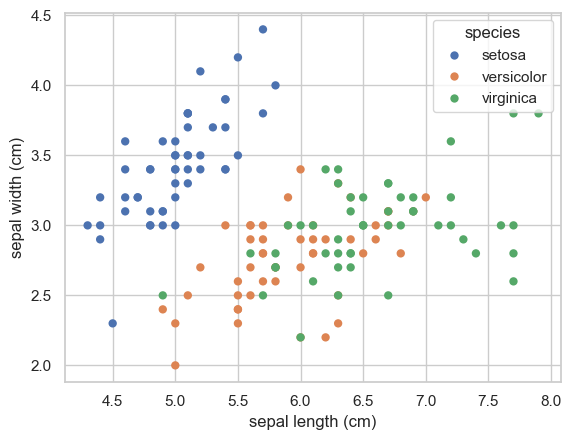

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")


sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)",
                hue="species",
                sizes=(1, 8), linewidth=0,
                data=pd.concat([iris_df,iris_targets], axis= 1))

<Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>

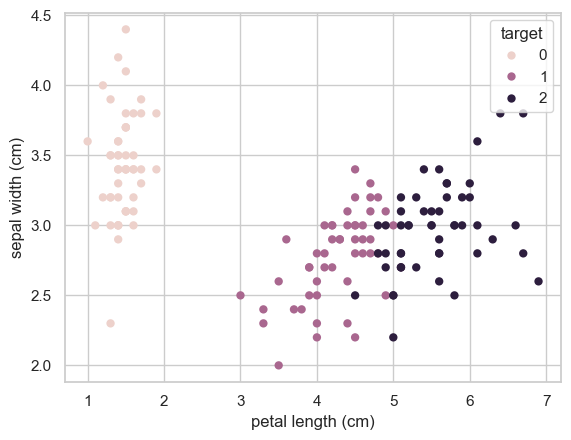

In [19]:
sns.scatterplot(x="petal length (cm)", y="sepal width (cm)",
                hue="target",
                sizes=(1, 8), linewidth=0,
                data=pd.concat([iris_df,iris_targets], axis=1))

Great but what if I don't have the targets!!

<Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>

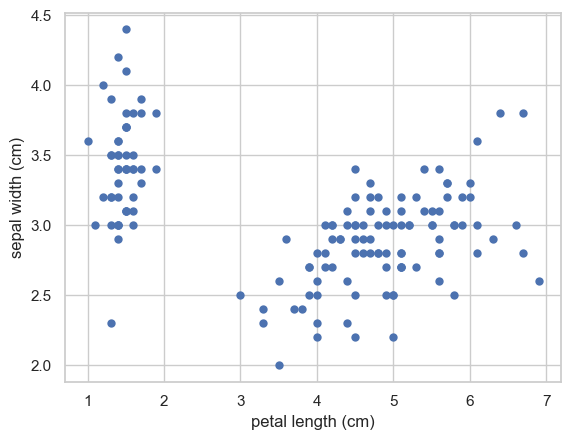

In [20]:
sns.scatterplot(x="petal length (cm)", y="sepal width (cm)",
                # hue="species",
                sizes=(1,8), linewidth=0,
                data=pd.concat([iris_df], axis=1))

This might seem all quiet complicated but we did Machine Learning in four lines of python 
1. Import the model from sklearn
2. Initialise and set Hyper-parameters
3. Train or 'Fit' the model to our data
4. Use it to make predictions!!

In [ ]:
# import KMeans 
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, n_init='auto', random_state=rng)
model = model.fit(iris_df)
predictions["cluster"] = model.predict(iris_df) 

In [ ]:
from sklearn.cluster import KMeans 

In [ ]:
model = KMeans(n_clusters=3, n_init="auto", random_state=rng)

In [23]:
model = model.fit(iris_df)

In [24]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
predictions = iris_df.copy()
predictions["cluster"] = model.predict(iris_df)
predictions

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


<Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>

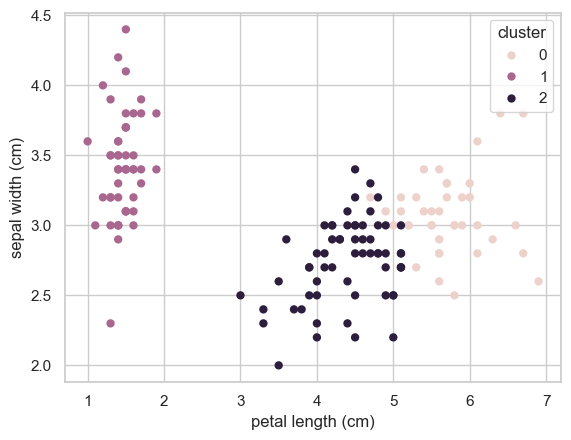

In [26]:
sns.scatterplot(x="petal length (cm)", y="sepal width (cm)",
                hue="cluster",
                sizes=(1, 8), linewidth=0,
                data=predictions)

In [27]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(iris_df, random_state=rng, test_size=0.2)

In [28]:
model = KMeans(3, n_init="auto", random_state=rng)

In [31]:
model = model.fit(train)

In [30]:
help(model.fit)

Help on method fit in module sklearn.cluster._kmeans:

fit(X, y=None, sample_weight=None) method of sklearn.cluster._kmeans.KMeans instance
    Compute k-means clustering.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training instances to cluster. It must be noted that the data
        will be converted to C ordering, which will cause a memory
        copy if the given data is not C-contiguous.
        If a sparse matrix is passed, a copy will be made if it's not in
        CSR format.

    y : Ignored
        Not used, present here for API consistency by convention.

    sample_weight : array-like of shape (n_samples,), default=None
        The weights for each observation in X. If None, all observations
        are assigned equal weight. `sample_weight` is not used during
        initialization if `init` is a callable or a user provided array.

        .. versionadded:: 0.20

    Returns
    -------
    self : object
    

In [32]:
train.count()

sepal length (cm)    120
sepal width (cm)     120
petal length (cm)    120
petal width (cm)     120
dtype: int64

In [33]:
test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
101,5.8,2.7,5.1,1.9
55,5.7,2.8,4.5,1.3
56,6.3,3.3,4.7,1.6
139,6.9,3.1,5.4,2.1
37,4.9,3.6,1.4,0.1
78,6.0,2.9,4.5,1.5
135,7.7,3.0,6.1,2.3
104,6.5,3.0,5.8,2.2
109,7.2,3.6,6.1,2.5
108,6.7,2.5,5.8,1.8


In [36]:
model.predict(train)

array([1, 2, 0, 2, 0, 0, 2, 1, 1, 2, 0, 0, 0, 0, 1, 0, 2, 2, 2, 1, 2, 1,
       2, 2, 2, 1, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 2, 0, 2, 1, 0, 0, 1, 0,
       0, 2, 1, 0, 1, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 0, 2, 0, 1, 2, 0,
       2, 2, 1, 2, 2, 2, 2, 2, 0, 0, 0, 2, 1, 0, 1, 0, 1, 1, 2, 0, 1, 1,
       1, 1, 2, 2, 0, 2, 2, 1, 0, 2, 1, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 2,
       2, 0, 0, 1, 2, 1, 2, 1, 2, 1], dtype=int32)

In [35]:
model.predict(test)

array([2, 2, 2, 0, 1, 2, 0, 0, 0, 0, 2, 0, 2, 1, 1, 1, 2, 1, 0, 1, 2, 2,
       1, 1, 0, 1, 1, 2, 1, 2], dtype=int32)

In [41]:
iris_targets.loc[16]

target          0
species    setosa
Name: 16, dtype: object

In [42]:
predictions_test = test.copy() 

predictions_test["predict"] = model.predict(test)
predictions_test['predict'] = predictions_test['predict'].apply(
    lambda x: 0 if x ==1 else (1 if x==0 else x)) 
predictions_test["target"] = predictions_test.index.map(iris_targets['target'])
predictions_test["species"] = predictions_test.index.map(iris_targets['species'])

In [43]:
predictions_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predict,target,species
101,5.8,2.7,5.1,1.9,2,2,virginica
55,5.7,2.8,4.5,1.3,2,1,versicolor
56,6.3,3.3,4.7,1.6,2,1,versicolor
139,6.9,3.1,5.4,2.1,1,2,virginica
37,4.9,3.6,1.4,0.1,0,0,setosa
78,6.0,2.9,4.5,1.5,2,1,versicolor
135,7.7,3.0,6.1,2.3,1,2,virginica
104,6.5,3.0,5.8,2.2,1,2,virginica
109,7.2,3.6,6.1,2.5,1,2,virginica
108,6.7,2.5,5.8,1.8,1,2,virginica


In [45]:
from sklearn.metrics import accuracy_score

In [46]:
predictions_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predict,target,species
101,5.8,2.7,5.1,1.9,2,2,virginica
55,5.7,2.8,4.5,1.3,2,1,versicolor
56,6.3,3.3,4.7,1.6,2,1,versicolor
139,6.9,3.1,5.4,2.1,1,2,virginica
37,4.9,3.6,1.4,0.1,0,0,setosa
78,6.0,2.9,4.5,1.5,2,1,versicolor
135,7.7,3.0,6.1,2.3,1,2,virginica
104,6.5,3.0,5.8,2.2,1,2,virginica
109,7.2,3.6,6.1,2.5,1,2,virginica
108,6.7,2.5,5.8,1.8,1,2,virginica


In [47]:
accuracy_score(predictions_test['target'], predictions_test['predict'])

0.5

In [48]:
setosa = predictions_test[predictions_test['species'] == 'setosa']
accuracy_score(setosa['target'], setosa['predict'])

1.0

In [49]:
versicolor = predictions_test[predictions_test['species'] == 'versicolor']
accuracy_score(versicolor['target'], versicolor['predict'])

0.0

In [50]:
virginica = predictions_test[predictions_test['species'] == 'virginica']
accuracy_score(virginica['target'], virginica['predict'])

0.3333333333333333

Understand ^^^ and then...
Try it yourself!!
Linear Regression with Diabetes Dataset
Data Wrangling

# Data Wrangling 

We will load the data from SKLean Toy Datasets 

In [51]:
diabetes = datasets.load_diabetes(scaled=False)

In [52]:
type(diabetes)

sklearn.utils._bunch.Bunch

How do we get this into a data frame? Lets look at the keys in the 'bunch' (its just a dictionary really)

In [53]:
diabetes.keys() 

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

Okay, let's use those keys to make us a dataframe for the Target Attributes: 

In [54]:
targets = pd.DataFrame(diabetes['target'], columns=['target'])

What feature names are there?

In [55]:
diabetes['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

These will be our column names for the **Data Attributes**

Now we can make a Data Frame for our Data Attributes: (This will contain all our Independent Variables)

In [56]:
df = pd.DataFrame(diabetes["data"], columns=diabetes["feature_names"])

In [57]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0
...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0


Okay lets train a linear model on the data 

In [58]:
## Import our model and model_selection
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Split our data into train and test

X_train, X_test, y_train, y_test = train_test_split(df, targets)

print(f"{X_train = } \n\n {y_train = }")

X_train =       age  sex   bmi      bp     s1     s2    s3    s4      s5     s6
166  33.0  2.0  20.8   84.00  125.0   70.2  46.0  3.00  3.7842   66.0
316  53.0  2.0  27.7   95.00  190.0  101.8  41.0  5.00  5.4638  101.0
185  28.0  2.0  24.7   97.00  175.0   99.6  32.0  5.00  5.3799   87.0
323  68.0  2.0  25.7  109.00  233.0  112.6  35.0  7.00  6.0568  105.0
388  63.0  2.0  24.1  111.00  184.0  112.2  44.0  4.00  4.9345   82.0
..    ...  ...   ...     ...    ...    ...   ...   ...     ...    ...
148  32.0  2.0  27.8   89.00  216.0  146.2  55.0  4.00  4.3041   91.0
163  53.0  2.0  33.1  117.00  183.0  119.0  48.0  4.00  4.3820  106.0
291  69.0  1.0  28.1  113.00  234.0  142.8  52.0  4.00  5.2781   77.0
265  39.0  2.0  24.0   89.67  190.0  113.6  52.0  3.65  4.8040  101.0
2    72.0  2.0  30.5   93.00  156.0   93.6  41.0  4.00  4.6728   85.0

[331 rows x 10 columns] 

 y_train =      target
166    70.0
316   220.0
185   101.0
323   248.0
388   110.0
..      ...
148    96.0
163   131.0
291 

In [59]:
y_train

,target
166,70.0
316,220.0
185,101.0
323,248.0
388,110.0
...,...
148,96.0
163,131.0
291,248.0
265,74.0


In [61]:
model = LinearRegression() 
# Model attributes are adjusted 
model.fit(X_train[["age"]], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
model.predict(X_test[["age"]])

array([[137.84956561],
       [164.55662271],
       [152.53844701],
       [164.55662271],
       [133.84350705],
       [140.52027132],
       [149.8677413 ],
       [167.22732842],
       [151.20309416],
       [135.1788599 ],
       [116.48391993],
       [164.55662271],
       [175.23944555],
       [153.87379987],
       [144.52632989],
       [140.52027132],
       [153.87379987],
       [184.58691553],
       [159.21521129],
       [165.89197556],
       [141.85562418],
       [152.53844701],
       [164.55662271],
       [136.51421276],
       [128.50209563],
       [171.23338698],
       [165.89197556],
       [185.92226839],
       [153.87379987],
       [175.23944555],
       [131.17280134],
       [167.22732842],
       [163.22126985],
       [140.52027132],
       [149.8677413 ],
       [176.5747984 ],
       [124.49603706],
       [124.49603706],
       [132.50815419],
       [152.53844701],
       [175.23944555],
       [155.20915272],
       [135.1788599 ],
       [175

In [63]:
# using the model for inference (prediction)
y_predict = model.predict(X_test[["age"]])
X = X_test[["age"]].copy()

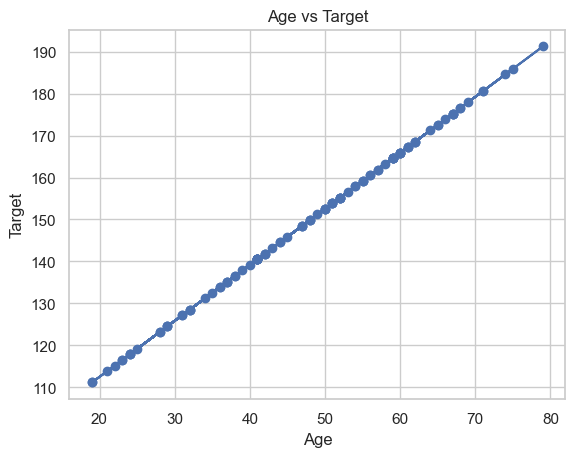

In [64]:
import matplotlib.pyplot as plt

plt.subplot()

# Create a line plot
plt.plot(X_test[["age"]], y_predict, marker='o')

# Add title and labels
plt.title('Age vs Target')
plt.xlabel('Age')
plt.ylabel('Target')

# Show the plot
plt.show()

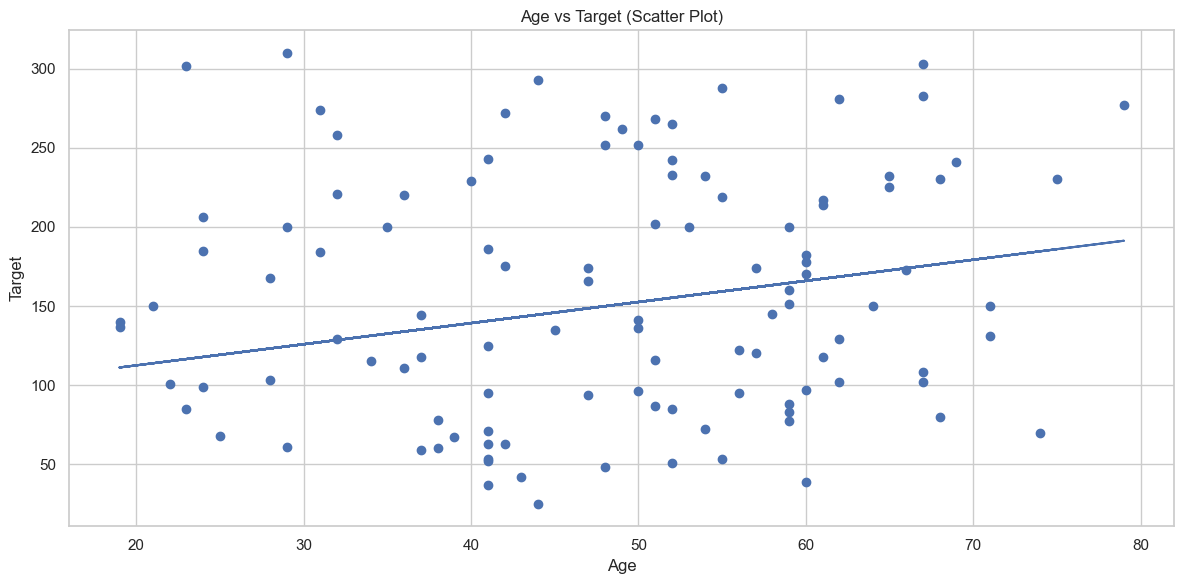

In [65]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Line plot on the first subplot 
ax.plot(X_test[["age"]], y_predict)
ax.set_title('Age vs Target (Line Plot)')
ax.set_xlabel('Age')
ax.set_ylabel('Target')

# Scatter plot on the second subplot 
ax.scatter(X_test[["age"]], y_test)
ax.set_title('Age vs Target (Scatter Plot)')
ax.set_xlabel('Age')
ax.set_ylabel('Target')

# show the plot 
plt.tight_layout() 
plt.show() 

In [66]:
y_test["target"].to_numpy()

array([ 67., 200., 252., 160., 220., 125.,  48., 214., 262., 118.,  85.,
        77., 102., 116.,  25.,  53., 268.,  70., 288.,  97.,  63., 136.,
        83.,  78., 258., 150.,  39., 230., 202., 108., 115., 118., 145.,
        95., 270., 230., 200.,  61., 200.,  96., 283.,  85.,  59., 303.,
       219., 217., 221., 225., 151.,  87.,  99., 274., 310.,  51.,  72.,
       103., 242., 232., 135., 101., 184., 182., 144., 111., 137.,  52.,
       150., 200., 229.,  53.,  95., 252., 122., 174., 120., 102., 206.,
       174.,  94., 243., 233., 281.,  80., 178., 170.,  60.,  63., 293.,
        37., 186., 129., 140., 241., 168., 185., 166., 131., 232., 265.,
       141.,  68., 302.,  71., 150., 129., 277., 175.,  88.,  42., 173.,
       272.])

In [67]:
y_predict.flatten()

array([137.84956561, 164.55662271, 152.53844701, 164.55662271,
       133.84350705, 140.52027132, 149.8677413 , 167.22732842,
       151.20309416, 135.1788599 , 116.48391993, 164.55662271,
       175.23944555, 153.87379987, 144.52632989, 140.52027132,
       153.87379987, 184.58691553, 159.21521129, 165.89197556,
       141.85562418, 152.53844701, 164.55662271, 136.51421276,
       128.50209563, 171.23338698, 165.89197556, 185.92226839,
       153.87379987, 175.23944555, 131.17280134, 167.22732842,
       163.22126985, 140.52027132, 149.8677413 , 176.5747984 ,
       124.49603706, 124.49603706, 132.50815419, 152.53844701,
       175.23944555, 155.20915272, 135.1788599 , 175.23944555,
       159.21521129, 167.22732842, 128.50209563, 172.56873984,
       164.55662271, 153.87379987, 117.81927279, 127.16674277,
       124.49603706, 155.20915272, 157.87985843, 123.16068421,
       155.20915272, 172.56873984, 145.86168274, 115.14856708,
       127.16674277, 165.89197556, 135.1788599 , 133.84

 Not how we should eveluate LinearRegression :

In [68]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test["target"].to_numpy().astype(int), y_predict.flatten().astype(int))

0.009009009009009009

In [69]:
# we could digitize ...
# y_true_cat = np.digitize(y_true, bins=[0.5])
# y_pred_cat = np.digitize(y_pred, bins=[0.5])

# or we can just use r^2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predict)

print(f"mean_absolute_error {mae}")
print(f"mean_squared_error {mse}")
print(f"Square Root mean_squared_error {rmse}")

mean_absolute_error 65.38319322441741
mean_squared_error 5869.688177523101
Square Root mean_squared_error 76.61389023880136


Not very good.. Lets try more dimensions

In [70]:
model = LinearRegression()
# Model attributes are adjusted
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
y_predict = model.predict(X_test)

In [72]:
## Lets re evaluate!
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predict)

print(f"mean_absolute_error {mae}")
print(f"mean_squared_error {mse}")
print(f"Square Root mean_squared_error {rmse}")
print(f"R2 {r2}")

mean_absolute_error 44.533092873333004
mean_squared_error 2944.8655913549514
Square Root mean_squared_error 54.26661580893866
R2 0.4902506016189675


Kind of better but still not great..
Maybe we can try scaling our data..

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

In [74]:
model = LinearRegression()
# Model attributes are adjusted
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
y_predict = model.predict(X_test)

In [76]:
## Lets re evaluate!
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predict)

print(f"mean_absolute_error {mae}")
print(f"mean_squared_error {mse}")
print(f"Square Root mean_squared_error {rmse}")
print(f"R2 {r2}")

mean_absolute_error 44.533092873332976
mean_squared_error 2944.865591354947
Square Root mean_squared_error 54.26661580893862
R2 0.49025060161896816


Not really any improvement.. we might need a different model to do better...¶
Huh, we got an error why?? -- This worked for KMeans??

# Scaling Example

In [77]:
from sklearn.preprocessing import StandardScaler

data = [
    [10_000,3.0],
    [20_000,2.5],
    [50_000,1.5],
    [25_000,1.4],
    [25_000,1.4],
    [15_000,1.4],
    [10_000,1.3],
    [35_000,1.2],
]

data_df = pd.DataFrame(data, columns =["distance","height"])

scaler = StandardScaler() 
scaler.fit(data)
scaled_data = scaler.transform(data) 


In [79]:
scaled_df = pd.DataFrame(scaled_data, columns =["distance", "height"])
scaled_df

,distance,height
0,-1.083862,2.085601
1,-0.295599,1.275659
2,2.069191,-0.344225
3,0.098533,-0.506214
4,0.098533,-0.506214
5,-0.689730,-0.506214
6,-1.083862,-0.668202
7,0.886796,-0.830191


<Axes: >

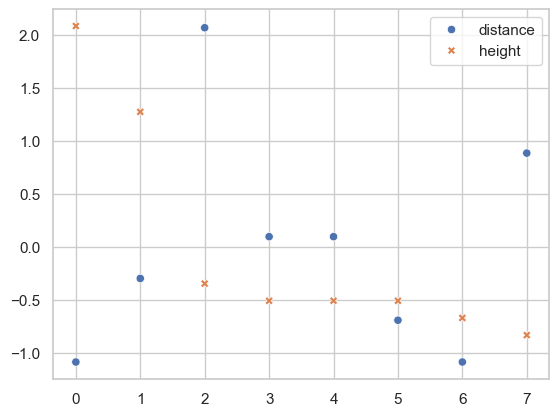

In [80]:
import seaborn as sns

sns.scatterplot(scaled_df)

<Axes: >

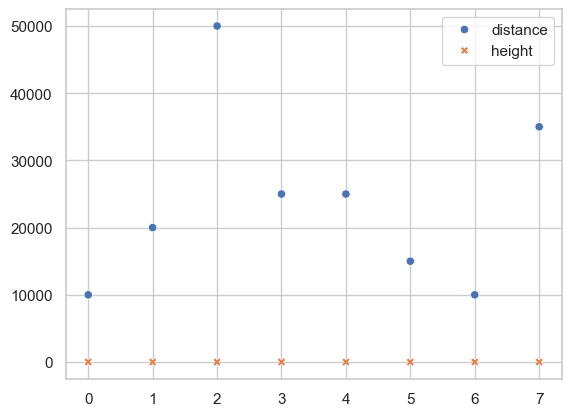

In [81]:
sns.scatterplot(data_df)

# Logistics regression with Iris example 

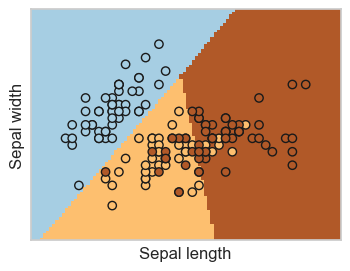

In [82]:
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features.
Y = iris.target

# Create an instance of Logistic Regression Classifier and fit the data.
logreg = LogisticRegression(C=1e5)
logreg.fit(X, Y)

_, ax = plt.subplots(figsize=(4, 3))

DecisionBoundaryDisplay.from_estimator(
    logreg,
    X,
    cmap=plt.cm.Paired,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
    xlabel="Sepal length",
    ylabel="Sepal width",
    eps=0.5,
)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors="k", cmap=plt.cm.Paired)


plt.xticks(())
plt.yticks(())

plt.show()